# Expressing DeepSeek-V3

This notebook writes the released DeepSeek-V3 as one expression and draws it part by part. It derives from the expression the pass that reads earlier tokens from caches, and it labels both passes with the quantisations the released inference code runs them at. The last cell writes an interactive page that switches between the four resulting forms.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

from IPython.display import Markdown, display

import notebooks.classic.cached_deepseek_v3 as cached_deepseek_v3
import notebooks.classic.deepseek_v3 as deepseek_v3
import notebooks.classic.deepseek_v3_page_variants as deepseek_v3_page_variants
import notebooks.classic.quantised_deepseek_v3 as quantised_deepseek_v3
import notebooks.classic.released_deepseek_v3 as released_deepseek_v3
import notebooks.display.explain_cached_reads as explain_cached_reads
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.website.website_output as website_output

DIAGRAMS = released_deepseek_v3.with_explanation_tables(figures.DiagramSettings(
    mode=figures.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    axis_sizes=figures.AxisSizes.SUBSCRIPT,
    assigned_sizes=released_deepseek_v3.released_assigned_sizes(),
    advanced_display=figures.AdvancedDisplay.LEGEND,
    title='DeepSeek-V3'))
QUANTISED_DIAGRAMS = quantised_deepseek_v3.with_quantised_explanation_tables(
    dataclasses.replace(DIAGRAMS, clean_quantisation_labels=False))
CACHED_DIAGRAMS = explain_cached_reads.with_cached_read_explanations(DIAGRAMS)
QUANTISED_CACHED_DIAGRAMS = explain_cached_reads.with_cached_read_explanations(
    QUANTISED_DIAGRAMS)

DECODE = released_deepseek_v3.decode_form()
CACHED = cached_deepseek_v3.CACHED_PASS.expression

## Reading the figures

A figure is a neural circuit diagram of one expression. Every wire is an array, and the label on a wire names one axis of the array, with the size assigned by the configuration written as a subscript. A wire passes through an operator when the operator is computed once for every index of that axis, and a wire ends at an operator when the operator consumes the axis. A block is a titled box around a part of the expression, and a block whose repetition is greater than one is a loop, drawn with the repetition at its left bracket. A named box, such as `At`, `Gate` or `RoPE`, stands for a block whose body is drawn in a figure of its own. In the figures of the quantised model a wire is also labelled with the quantisation its values are held in, such as BF16.

The sizes are those of `config_671B.json`, the configuration of the released checkpoint ([`config_671B.json` L1-L22](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L1-L22)), with the defaults of `ModelArgs` for what the file leaves out ([L55-L86](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L55-L86)).

| axis | size | what it indexes |
| --- | --- | --- |
| `x` | set by the input | the token positions of the sequence |
| `w` | the size of `x` | the slots of a token, slot $i_w$ holding the token $i_w$ before it |
| `m` | 7168 | the model width, `dim` in the released code |
| `h` | 128 | the attention heads |
| $\ell_q$ | 1536 | the query latent, `q_lora_rank` |
| $\ell$ | 512 | the key-value latent, `kv_lora_rank` |
| $d_n$, $d_r$, $d$ | 128, 64, 192 | the query and key channels that carry no position, the channels the rotary embedding turns, and both laid end to end |
| $d_v$ | 128 | the width of one value |
| `t` | 32 | the pairs of the $d_r$ channels |
| `u` | 18432 | the inner width of the dense multi-layer perceptron, `inter_dim` |
| `n`, $\lvert k \rvert$ | 256, 8 | the routed experts, and the routed experts each token reads |
| `g`, `j` | 8, 32 | the groups of experts, `n_expert_groups`, and the experts of one group |
| `b`, `p`, `c` | 2, 4, 128 | the best scores that score a group, the groups kept, `n_limited_groups`, and the experts of the kept groups |
| `f`, `s` | 2048, 2048 | the inner width of a routed expert, `moe_inter_dim`, and of the one shared expert |
| $\bar{v}$ | 129280 | the vocabulary |

## Multi-head latent attention

The keys and the values of every head are projected from one latent of $\ell = 512$ values per token ([L430-L432](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L430-L432)). A cache of earlier tokens can therefore hold the latent and one turned key of 64 values per token, where standard attention holds a key and a value for every head. Each of the 128 heads has a query and a key of $d = 192$ channels. The first $d_n = 128$ carry no position, and the last $d_r = 64$ are turned by the rotary embedding ([L466-L476](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L466-L476)).

`config_671B.json` sets a rank of 1536 for the queries ([`config_671B.json` L16](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L16)). $W^{DQ}$ projects the hidden state to a query latent of $\ell_q = 1536$ values, an RMSNorm normalises it, and $W^{UQ}$ and $W^{QR}$ project it to the two runs of channels of every head ([L427-L429](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L427-L429), [L464](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L464)). $W^{DKV}$ projects the hidden state to the key-value latent, an RMSNorm normalises it, and $W^{UK}$ and $W^{UV}$ project it to the key channels that carry no position and to the values. $W^{KR}$ projects the hidden state to the turned key channels once per token, and every head reads them. The released code holds $W^{UQ}$ with $W^{QR}$, $W^{DKV}$ with $W^{KR}$, and $W^{UK}$ with $W^{UV}$ as one weight each and splits the output of each. A linear map followed by a slice of its output is the linear map whose weight is that slice of the rows, so the expression writes one map for each part.

The released code adds $-\infty$ to the score of every later token ([L788-L789](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L788-L789), [L488-L489](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L488-L489)). The expression writes the causal mask as a read through the view named Mask. Slot $i_w$ of token $i_x$ reads token $i_x - i_w$, so slot 0 is the token itself and no slot reads a later token. A slot before the first token names a negative position and holds the unit, which the softmax and the weighted sum ignore. The figure draws the mask at the copy of the hidden state that feeds the keys and the values, and it draws the key and value projections over the tokens and the slots. Each of those projections acts on one token at a time, so projecting the hidden state read at token $i_x - i_w$ gives the key or the value that the released code projects at that token and reads through its mask.

Multi-head latent attention with the causal mask at the copy of the hidden state: the queries through their low rank, the keys and the values of every earlier token generated from the latent, and scaled dot-product attention for every head.


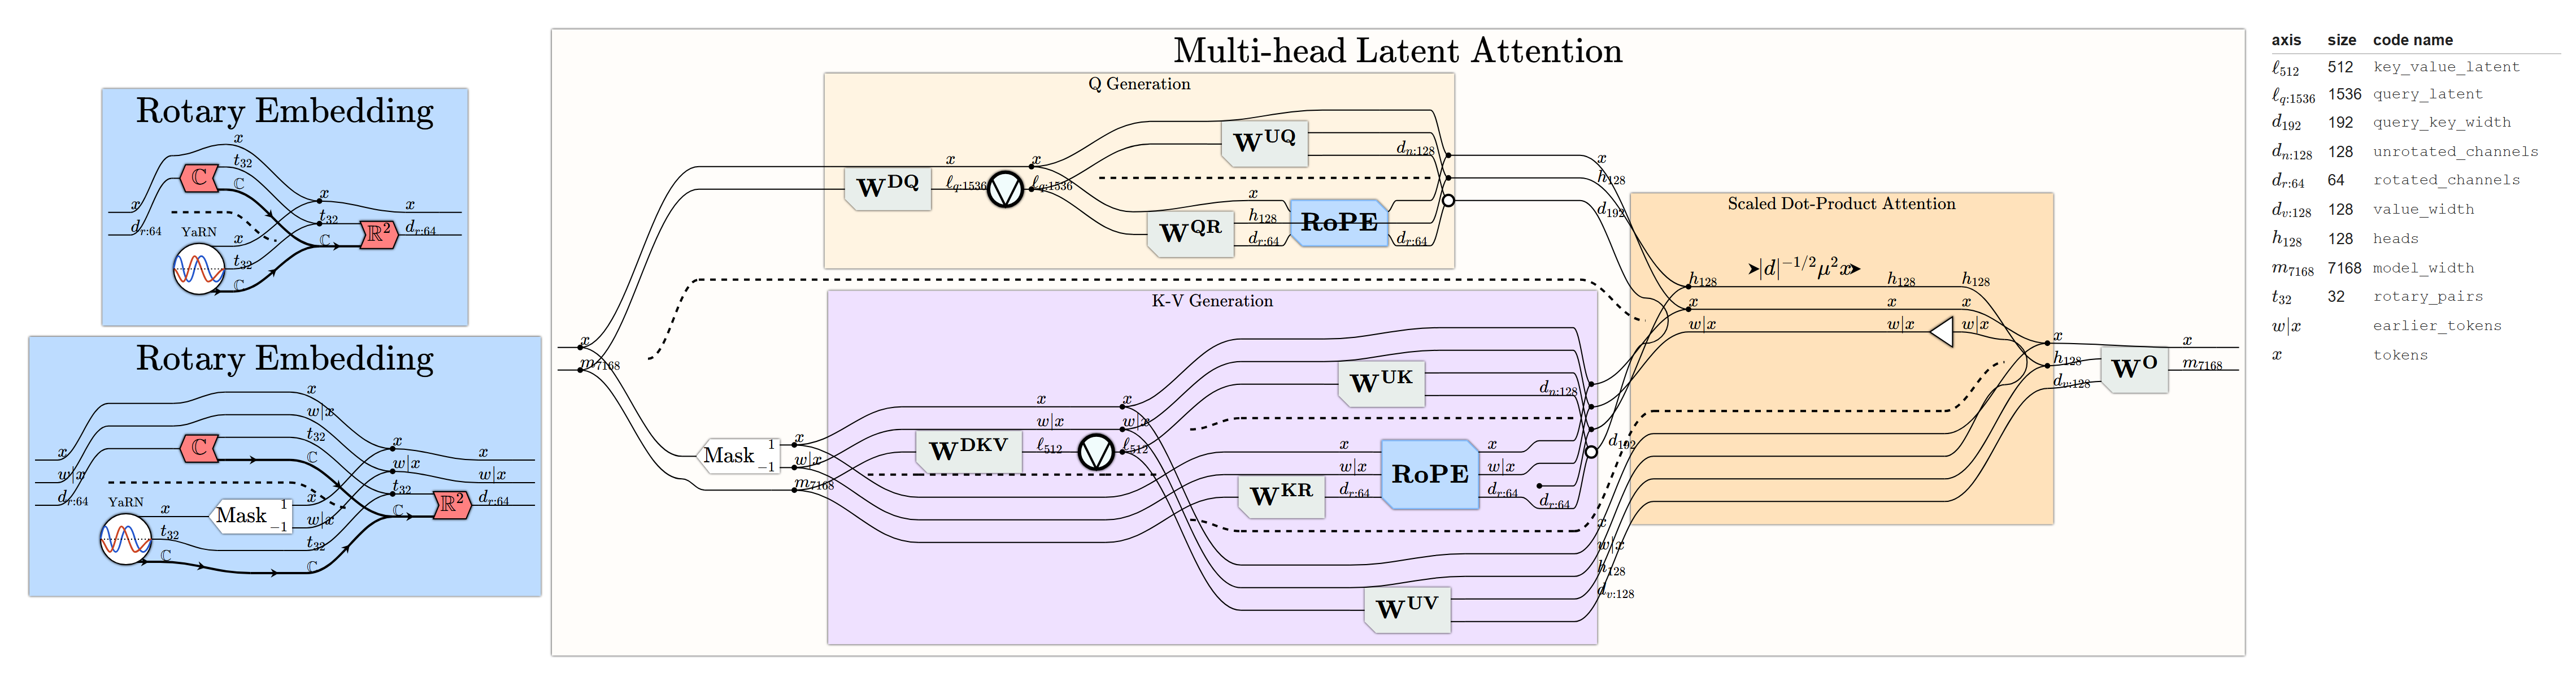

In [2]:
attention = released_deepseek_v3.multi_head_latent_attention()

await figures.show(
    released_deepseek_v3.decode_form(attention),
    'Multi-head latent attention with the causal mask at the copy of the hidden state: '
    'the queries through their low rank, the keys and the values of every earlier '
    'token generated from the latent, and scaled dot-product attention for every head.',
    width=2200, settings=DIAGRAMS)

## The rotary embedding and YaRN

The $d_r$ channels of a query or a key are read as 32 complex numbers. Each is multiplied by the entry that a table holds for its position and its pair, and the pairs are written back as channels ([L378-L393](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L378-L393)). The released code builds the table with YaRN whenever its maximum sequence length, 16384 by default, exceeds the 4096 tokens of the original context ([L56](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L56), [L81](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L81), [L367-L370](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L367-L370)). YaRN divides the angular velocity of the slow pairs by $\kappa = 40$ and fades between the two ends of a ramp, from pair $\mathrm{lo}$ to pair $\mathrm{hi}$, which `find_correction_range` computes ([L314-L345](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L314-L345)). The rotary embedding is the box `RoPE`, written over the $d_r$ channels of one token. The queries compute it once per head, and the turned key, which every head shares, computes it once per token.

The released code also multiplies the scale of the scores by $\mu^2$, with $\mu = 0.1\, m_c \ln \kappa + 1$ ([L434-L437](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L434-L437)). `config_671B.json` leaves the factor $m_c$ at its default of 1 ([L86](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L86)), so $\mu = 1.3689$ and the scores are multiplied by $192^{-1/2} \mu^2 = 0.13523$. The cell below computes the two ends of the ramp and the scale of the scores with the released formulas.

The rotary embedding as the box RoPE beside its body: the pairs read as complex numbers, multiplied by the YaRN table, and written back as channels.


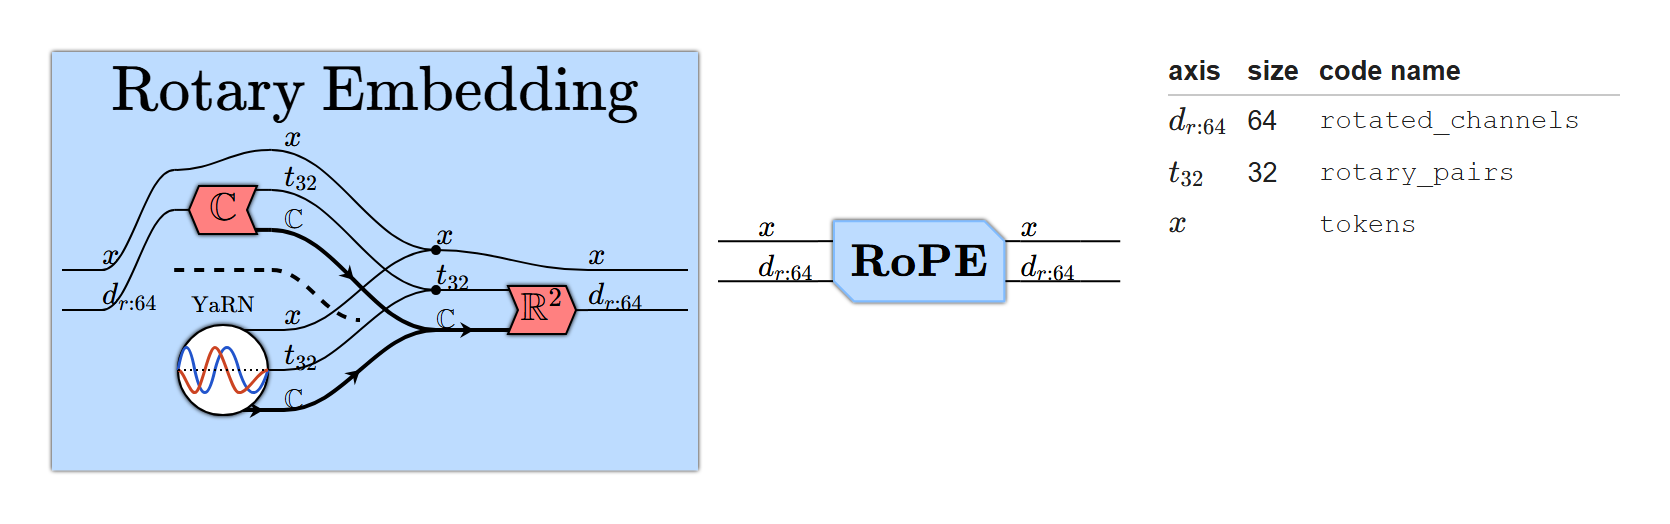

ramp from pair 10 to pair 23, mu = 1.3689, score scale = 0.13523


In [3]:
await figures.show(
    deepseek_v3.ROTARY_EMBEDDING,
    'The rotary embedding as the box RoPE beside its body: the pairs read as '
    'complex numbers, multiplied by the YaRN table, and written back as channels.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=DIAGRAMS)

ramp_start, ramp_end = released_deepseek_v3.yarn_ramp()
print(f'ramp from pair {ramp_start} to pair {ramp_end}, '
      f'mu = {released_deepseek_v3.attention_factor():.4f}, '
      f'score scale = {released_deepseek_v3.score_scale():.5f}')

## The gate and the groups of experts

Every layer after the third holds 256 routed experts, of which each token reads eight, and one shared expert, which every token reads ([L636-L693](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L636-L693), [`config_671B.json` L9-L11](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L9-L11)). The gate projects the hidden state to one score per routed expert and applies the sigmoid ([L576-L580](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L576-L580)). A learned correction bias, one number per expert, is added to one copy of the scores, and that copy alone decides which experts run ([L582-L583](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L582-L583)). The 256 experts form 8 groups of 32 ([L585](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L585), [`config_671B.json` L12-L13](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L12-L13)). Each group is scored by the sum of its two highest biased scores, the four best groups are kept, and the eight highest biased scores among the 128 experts of the kept groups choose the experts ([L589-L593](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L589-L593)). The unbiased scores of the chosen experts are divided by their sum and multiplied by the route scale $\gamma = 2.5$ ([L594-L597](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L594-L597), [`config_671B.json` L14](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L14)). The bias therefore changes which experts run and never scales the output of an expert.

The expression reads the biased scores as 8 groups of 32 through the view named Group. The two highest scores of each group are handed out as values alone, because only their sum is read. The four best groups are handed out as positions alone, because no score of a group is read again. The positions of the experts of the kept groups are laid out along the candidate axis $c$ of 128 positions, the biased scores are read there, and the eight best candidates are handed out on the sparse axis $k/n$, whose live positions are the chosen experts. The unbiased scores are then read at those positions and multiplied by the indicator of a positive biased score. Every correction bias of the released checkpoint lies between 2.02 and 8.05, read from its shards on 2026-09-27 ([shard 1](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00001-of-000163.safetensors)), and every sigmoid lies between 0 and 1. Every biased score is therefore positive, and the indicator is one at each chosen expert. The gate computes the same map at every token, so it is the box `Gate`, computed once per token, and the figure draws its body for one token.

The gate of one token: the sigmoid scores, the correction bias added to one copy, the four best groups of experts kept, the eight best experts of those groups chosen, and their unbiased scores normalised and scaled.


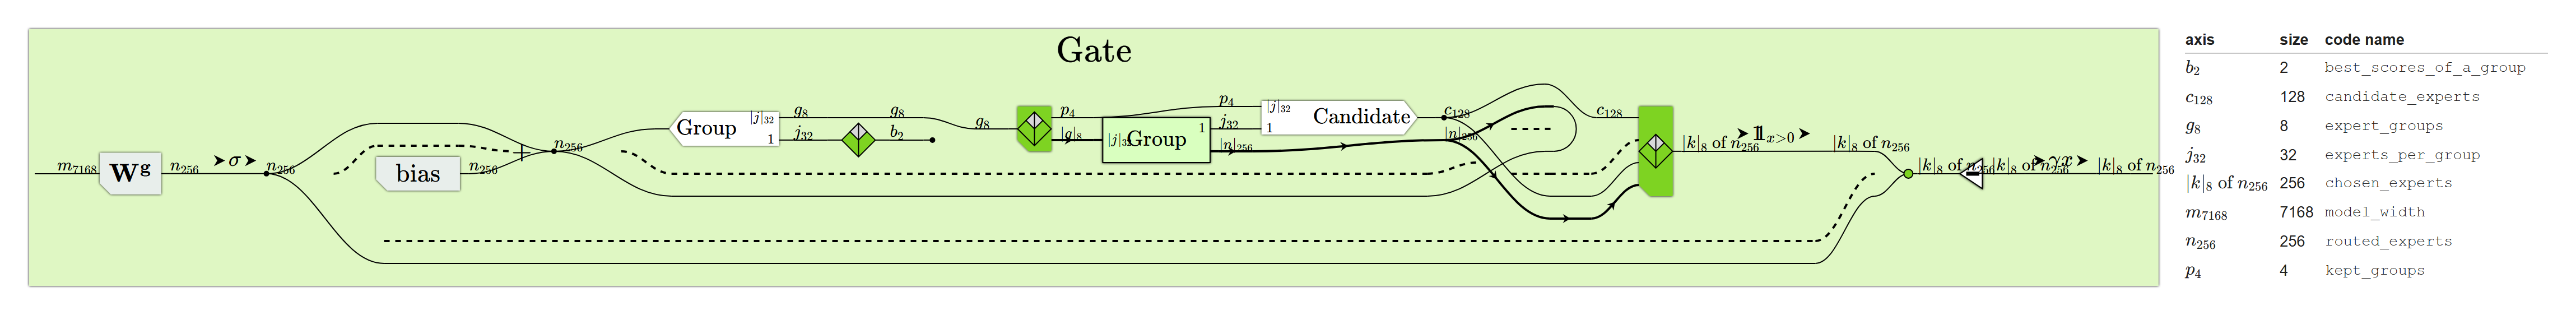

In [4]:
await figures.show(
    released_deepseek_v3.GATE_BODY,
    'The gate of one token: the sigmoid scores, the correction bias added to one copy, '
    'the four best groups of experts kept, the eight best experts of those groups '
    'chosen, and their unbiased scores normalised and scaled.',
    width=2000, settings=DIAGRAMS)

## The DeepSeek mixture of experts

Each routed expert is a SwiGLU with an inner width of $f = 2048$ ([L601-L633](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L601-L633), [`config_671B.json` L5](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L5)). The routed experts are one block whose projections hold the weights of all 256 experts and read those of the eight each token chose, through the sparse axis $k/n$. The view named Diagonal keeps the output of the expert each slot chose. The gates multiply the outputs of the chosen experts and the products are summed, which the expression writes as one contraction over the slots ([L684-L689](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L684-L689)). The shared expert is a SwiGLU of the same width that every token reads, and its output is added to the sum ([L667](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L667), [L690-L693](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L690-L693)).

The DeepSeek mixture of experts: the box Gate choosing and weighting eight experts, the routed experts with the diagonal after their second projection, the shared expert, and the weighted sum of the routed experts added to the shared expert.


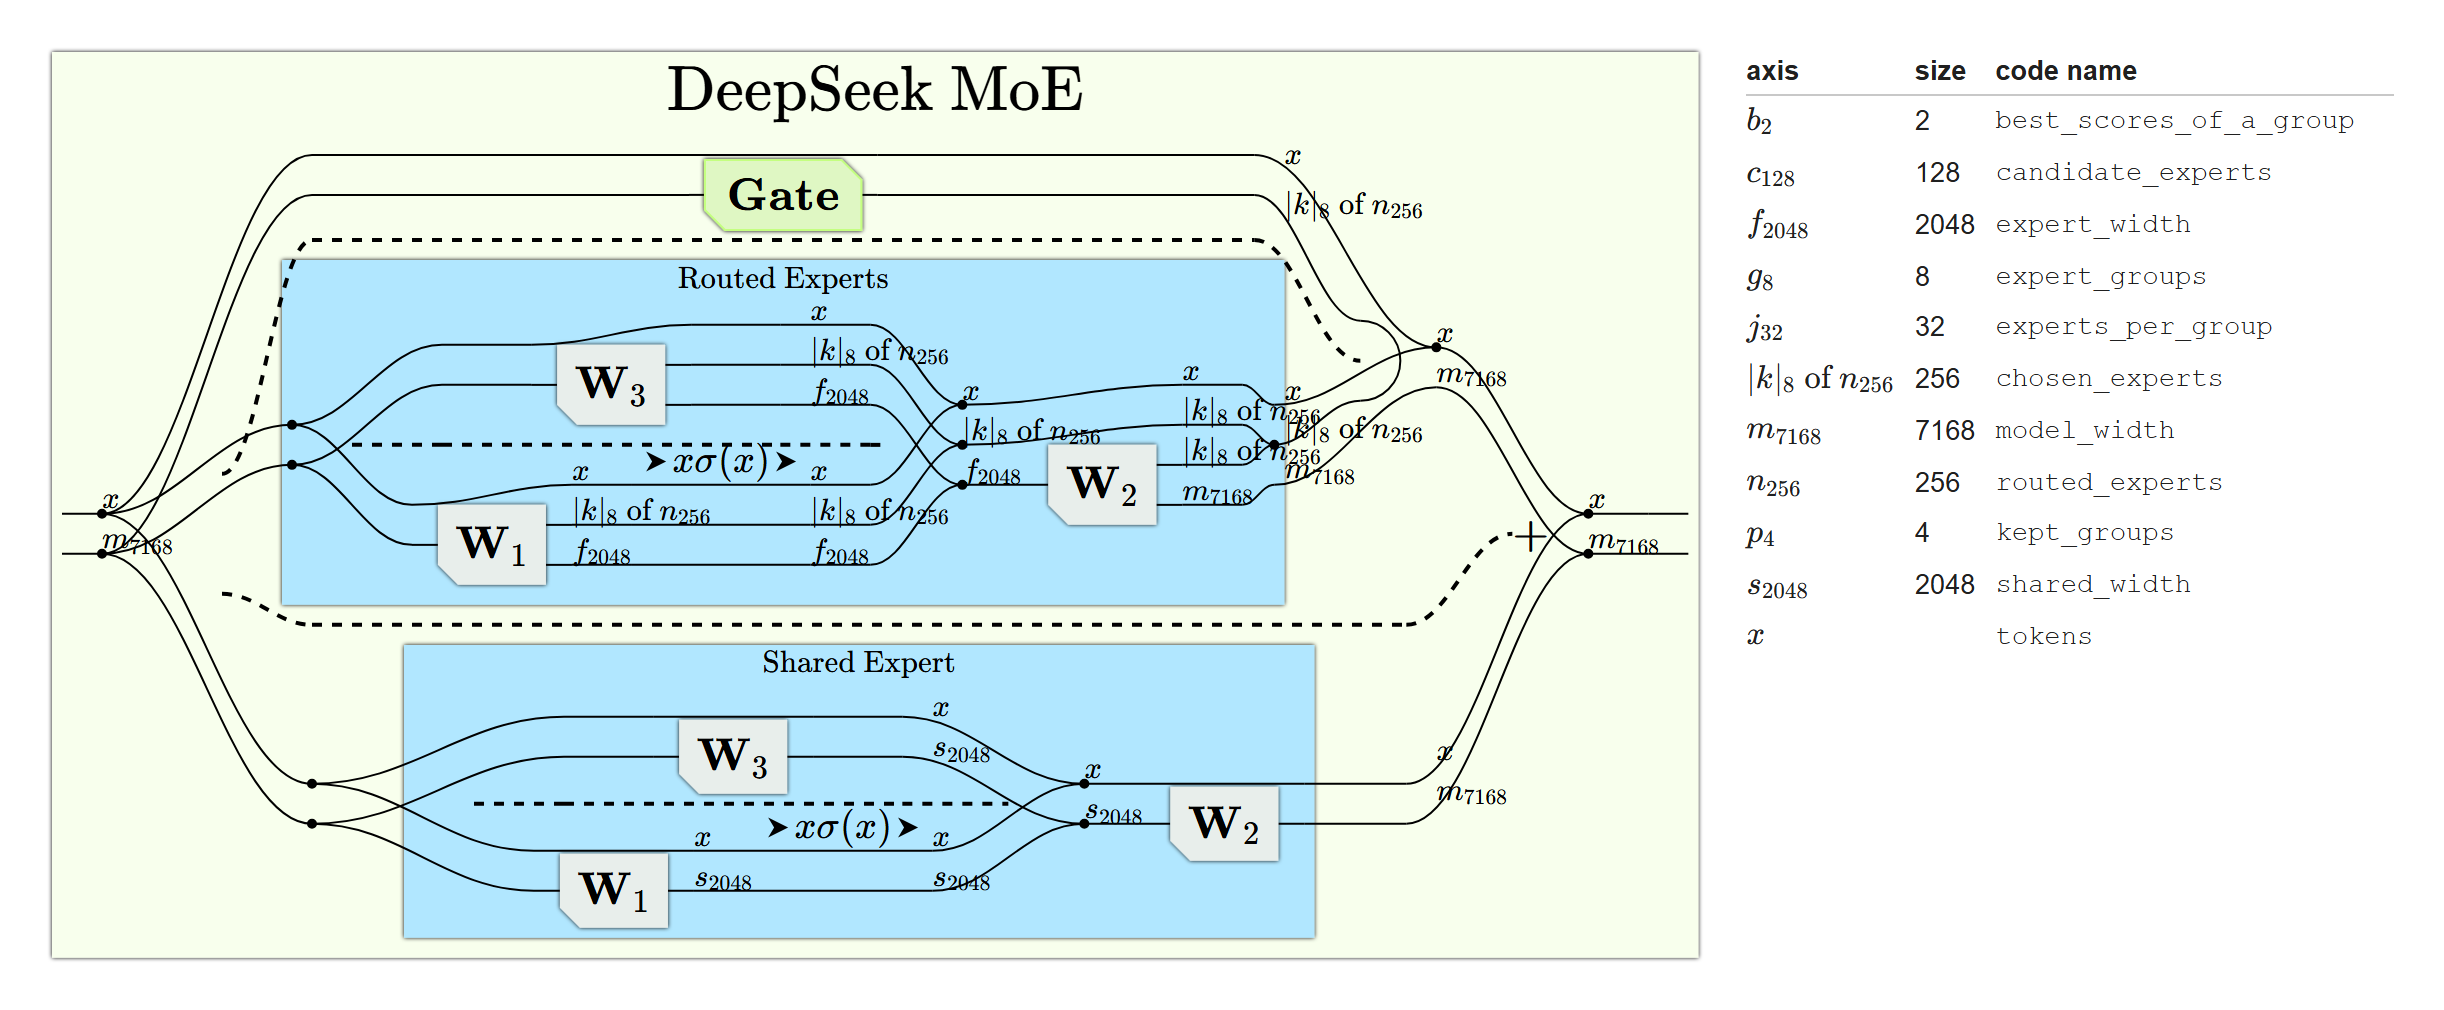

In [5]:
await figures.show(
    released_deepseek_v3.deepseek_mixture_of_experts(),
    'The DeepSeek mixture of experts: the box Gate choosing and weighting eight '
    'experts, the routed experts with the diagonal after their second projection, the '
    'shared expert, and the weighted sum of the routed experts added to the shared '
    'expert.',
    width=1400, sub_blocks=figures.SubBlocks.NO_BODIES, settings=DIAGRAMS)

## The layers and the whole model

The token identifiers are embedded into vectors of 7168 values ([L764](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L764)). The first $D = 3$ layers hold the dense multi-layer perceptron, a SwiGLU with an inner width of 18432, and the later $L = 58$ layers hold the mixture of experts, 61 layers in all ([L716](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L716), [`config_671B.json` L6-L7](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L6-L7)). Every layer adds the attention of the RMSNorm of the hidden state to the hidden state, and then adds its feed-forward sublayer of the RMSNorm of the result ([L733-L734](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L733-L734)). A final RMSNorm and the head give one score for every token of the vocabulary ([L768-L769](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L768-L769)). The figure draws the boxes `At`, `MLP` and `MoE` with their bodies left out, because the sections above draw each body.

DeepSeek-V3: the embedding, the dense layer repeated D times, the mixture layer repeated L times, and the output projection.


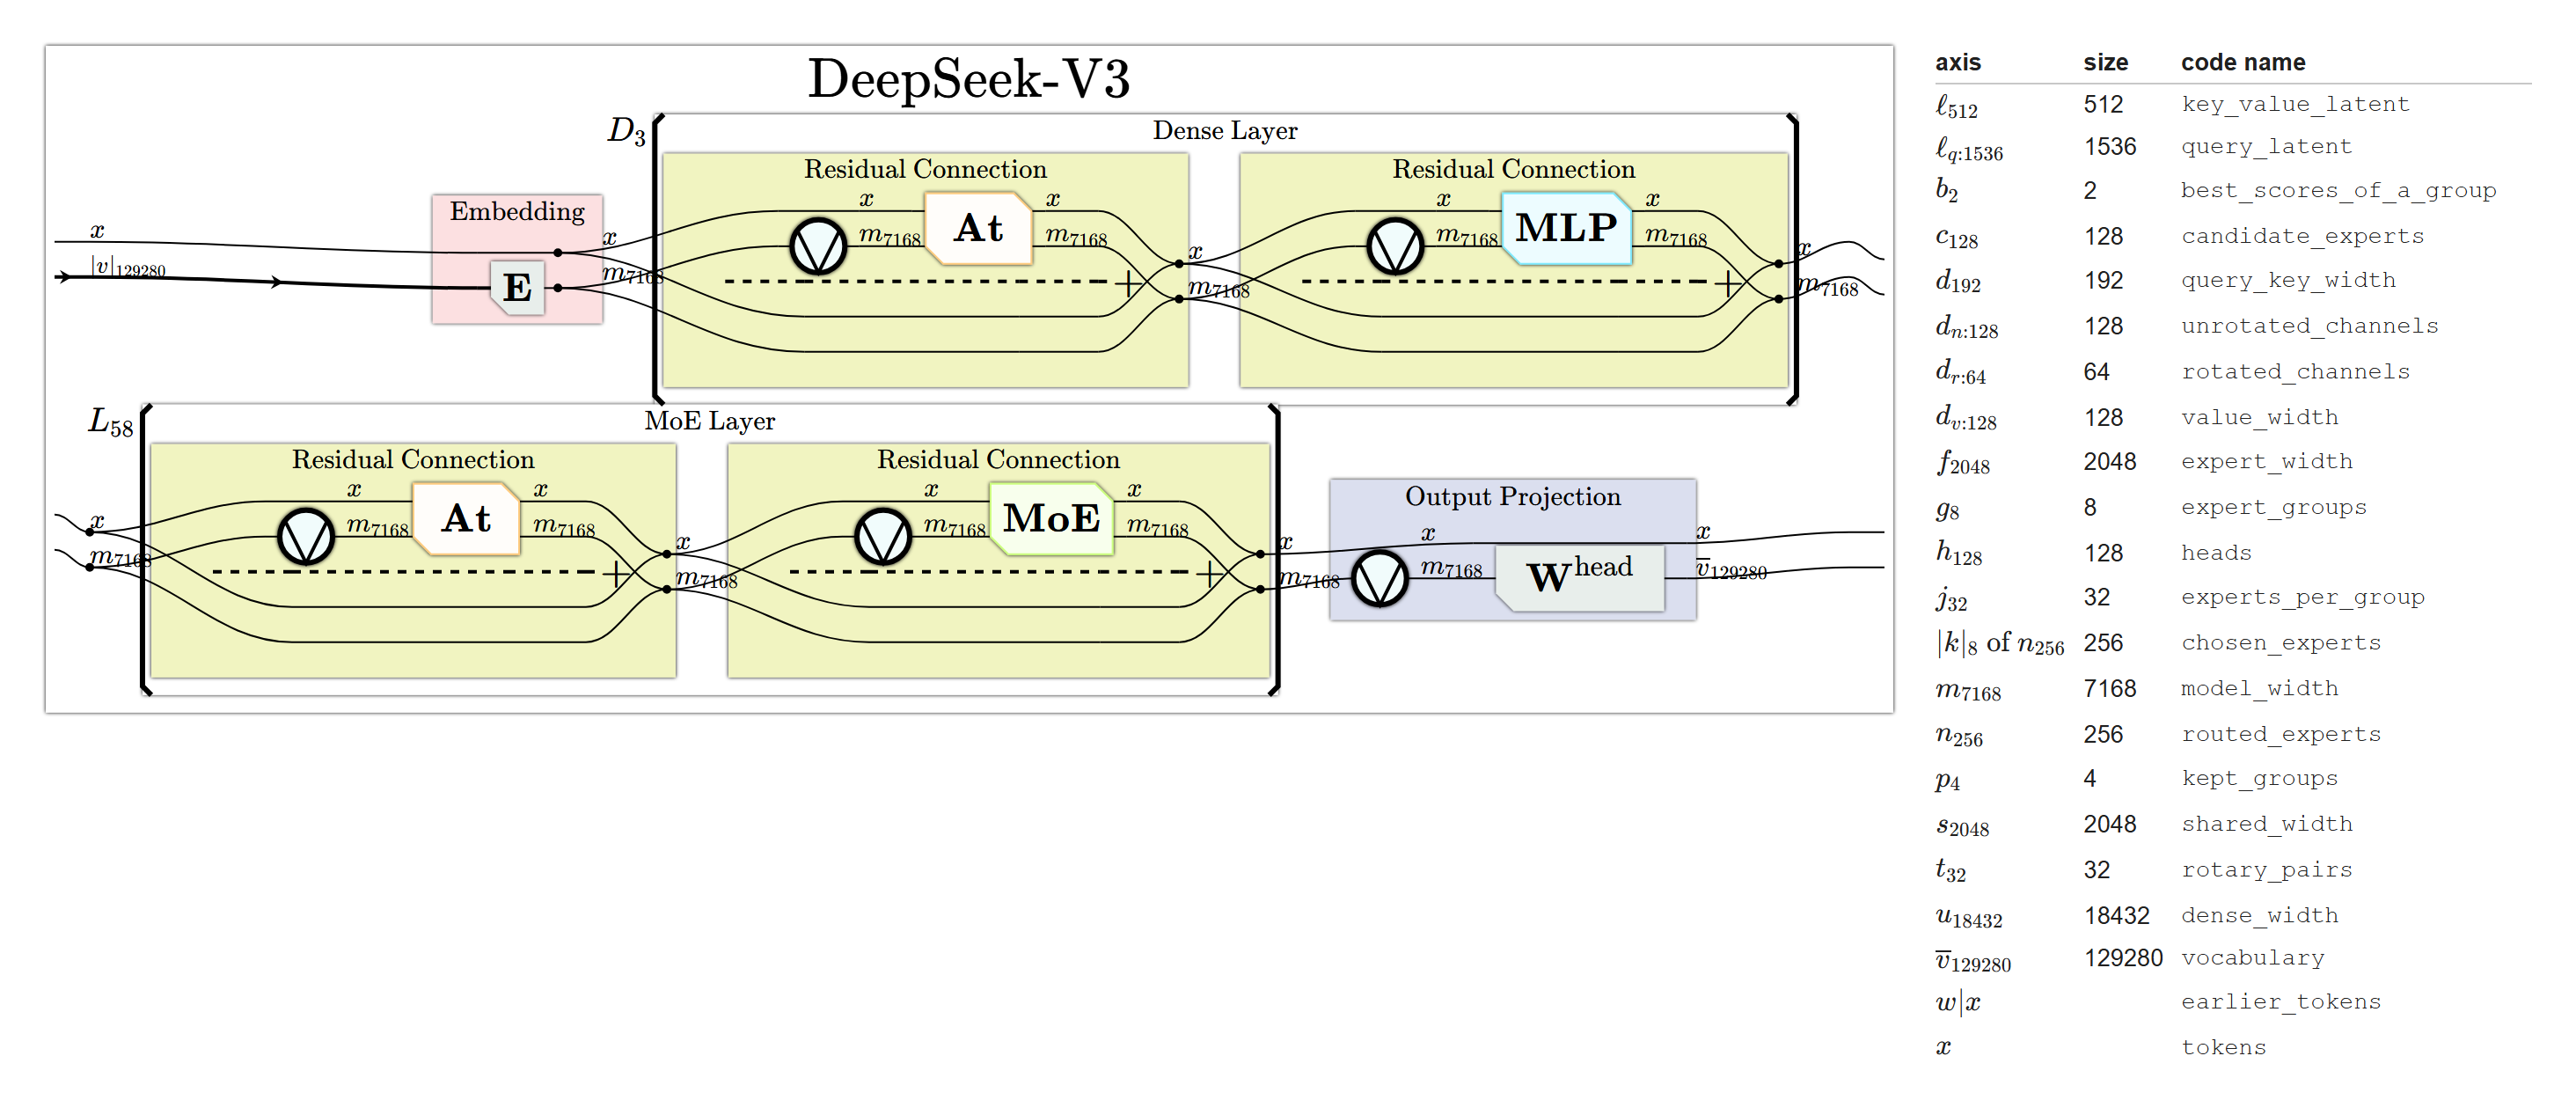

In [6]:
await figures.show(
    DECODE,
    'DeepSeek-V3: the embedding, the dense layer repeated D times, the mixture layer '
    'repeated L times, and the output projection.',
    width=960, sub_blocks=figures.SubBlocks.NO_BODIES, settings=DIAGRAMS)

## The quantisations of the released code

A quantisation is the number format a value is held in, together with the size of that format in bits. `config_671B.json` sets `dtype` to `fp8` ([`config_671B.json` L21](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L21)), so every linear map of the model holds its weight in E4M3, an 8-bit floating-point format, with one FP32 scale for every block of 128 rows by 128 channels ([L183-L187](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L183-L187), [L760](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L760), [`README_WEIGHTS.md` L60-L92](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/README_WEIGHTS.md#L60-L92)). The headers of the checkpoint's shards hold every projection as `F8_E4M3` beside an `F32` scale, the embedding, the router weight, the norms and the head as BF16, and the correction bias as FP32 ([shard 1](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00001-of-000163.safetensors), [shard 160](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00160-of-000163.safetensors), read on 2026-09-27).

The released `linear` has two ways to multiply by a weight held in FP8 ([L131-L163](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L131-L163)). The first multiplies every block of the weight by its scale into BF16 with `weight_dequant` and calls `F.linear` in BF16 ([`kernel.py` L89-L110](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/kernel.py#L89-L110)). The second rounds the activation to E4M3 with one FP32 scale per 128 channels through `act_quant` and multiplies in E4M3 with `fp8_gemm` ([`kernel.py` L38-L57](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/kernel.py#L38-L57), [`kernel.py` L175-L196](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/kernel.py#L175-L196)). The module sets `gemm_impl = "bf16"`, which selects the first ([L16](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L16)). `generate.py` sets the default dtype to BF16 and then builds and loads the model without assigning `gemm_impl` ([`generate.py` L100-L119](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/generate.py#L100-L119)). The released code therefore converts every FP8 weight to BF16 before its product and never rounds an activation to FP8. The expression carries BF16 on the operand of every FP8 projection.

Every tensor passed from one module to the next is BF16, because the default dtype is BF16. The attention, the multi-layer perceptron, the experts and the gate compute on BF16 tensors without converting them, and the softmax computes in FP32 and converts its result back to BF16 ([L490](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L490)). The RMSNorm is `F.rms_norm` of PyTorch 2.4.1, the version pinned by `requirements.txt`, which computes it as a chain of BF16 tensor operations ([`layer_norm.cpp` L266-L309](https://github.com/pytorch/pytorch/blob/ee1b6804381c57161c477caa380a840a84167676/aten/src/ATen/native/layer_norm.cpp#L266-L309), [`requirements.txt` L1](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/requirements.txt#L1)). The rotary embedding reads its pairs into FP32 and converts the result back to BF16 ([L389-L393](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L389-L393)). The correction bias is FP32, so adding it converts the copy of the scores to FP32, and the choice of the groups and the experts runs in FP32 ([L564](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L564), [L582-L593](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L582-L593)). The first table lists every quantisation with the lines it is read from. The second gives the quantisation of every weight, and the third counts the conversions written into the two passes.

In [7]:
display(Markdown(quantised_deepseek_v3.policy_table()))
display(Markdown(quantised_deepseek_v3.weight_table()))
display(Markdown(quantised_deepseek_v3.cast_table()))

| quantisation | what it applies to | lines |
|---|---|---|
| E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | every projection of the attention, the dense MLP, the routed experts and the shared expert. `config_671B.json` sets `dtype` to `fp8`, so `Linear.dtype` is `torch.float8_e4m3fn`, and every `Linear` allocates an FP32 scale per block of 128 by 128. The checkpoint holds each of them as `F8_E4M3` beside an `F32` `weight_scale_inv` | [inference/configs/config_671B.json L21](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L21), [inference/model.py L760](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L760), [inference/model.py L183-L187](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L183-L187), [README_WEIGHTS.md L60-L92](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/README_WEIGHTS.md#L60-L92), [config.json L37-L45](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/config.json#L37-L45), [model-00001-of-000163.safetensors](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00001-of-000163.safetensors) |
| BF16, 16 bits, packed 2 to a word | the operand of every FP8 projection, which is not rounded. The default `gemm_impl` is `bf16`, `generate.py` never assigns it, and under it `linear` dequantises the weight to the default dtype with `weight_dequant` and calls `F.linear` in BF16. The other path, `act_quant` and `fp8_gemm`, is not run | [inference/model.py L16](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L16), [inference/model.py L153-L163](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L153-L163), [inference/kernel.py L89-L110](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/kernel.py#L89-L110), [inference/generate.py L100-L119](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/generate.py#L100-L119) |
| BF16, 16 bits, packed 2 to a word | every tensor passed from one module to the next, because `generate.py` sets the default dtype to BF16 before it builds the model: the embedding, the result of every projection, every RMSNorm, the residual, the turned channels, the output of the attention, of the MLP and of the mixture, the gates and the logits | [inference/generate.py L109-L116](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/generate.py#L109-L116), [inference/model.py L124](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L124), [inference/model.py L393](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L393), [inference/model.py L490](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L490), [inference/model.py L598](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L598), [inference/model.py L682-L693](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L682-L693), [inference/model.py L733-L734](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L733-L734), [inference/model.py L769](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L769) |
| BF16, 16 bits, packed 2 to a word | the RMSNorm, which PyTorch 2.4.1 writes as a chain of tensor operations on the BF16 input and the BF16 weight, each rounding to BF16 | [inference/model.py L294](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L294), [PyTorch 2.4.1 aten/src/ATen/native/layer_norm.cpp L266-L309](https://github.com/pytorch/pytorch/blob/ee1b6804381c57161c477caa380a840a84167676/aten/src/ATen/native/layer_norm.cpp#L266-L309), [inference/requirements.txt L1](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/requirements.txt#L1) |
| BF16, 16 bits, packed 2 to a word | the arithmetic of the attention, the MLP, the experts and the gate: the score scale, the SiLU and the product of the two branches, the sigmoid of the router, the division of the gates by their sum and the route scale. The softmax computes in FP32 and returns BF16 through `.type_as(x)` | [inference/model.py L479](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L479), [inference/model.py L486-L490](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L486-L490), [inference/model.py L532](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L532), [inference/model.py L580](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L580), [inference/model.py L594-L598](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L594-L598), [inference/model.py L633](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L633) |
| FP32, 32 bits | the rotary embedding, which reads the pairs into FP32 and multiplies them by the complex64 table before writing BF16 back | [inference/model.py L366-L374](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L366-L374), [inference/model.py L389-L393](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L389-L393) |
| FP32, 32 bits | the correction bias, created in FP32 and held as `F32` in the checkpoint, and the copy of the scores it is added to, so the choice of the groups and the experts runs in FP32 | [inference/model.py L564](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L564), [inference/model.py L582-L593](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L582-L593), [model-00001-of-000163.safetensors](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00001-of-000163.safetensors) |
| BF16, 16 bits, packed 2 to a word | the token embedding, the router weight and the head, created in the default dtype and held as BF16 in the checkpoint | [inference/model.py L105](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L105), [inference/model.py L563](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L563), [inference/model.py L769](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L769), [model-00001-of-000163.safetensors](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00001-of-000163.safetensors), [model-00160-of-000163.safetensors](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/e815299b0bcbac849fa540c768ef21845365c9eb/model-00160-of-000163.safetensors) |
| INT64, 64 bits | the token identifiers, held in `torch.long`, and the positions picked by each top-k | [inference/generate.py L54-L56](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/generate.py#L54-L56), [inference/model.py L590](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L590), [inference/model.py L593](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L593) |
| BF16, 16 bits, packed 2 to a word | the two caches of the pass, the normalised latent and the turned key, which are buffers created in the default dtype | [inference/model.py L443-L444](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L443-L444), [inference/model.py L484-L485](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L484-L485) |

| weight | held in memory and in the checkpoint | read by the product as |
|---|---|---|
| $E$ | BF16, 16 bits, packed 2 to a word | the same |
| $W^{DKV}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{DQ}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{KR}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{O}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{QR}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{UK}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{UQ}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{UV}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W^{\mathrm{head}}$ | BF16, 16 bits, packed 2 to a word | the same |
| $W^{g}$ | BF16, 16 bits, packed 2 to a word | the same |
| $W{1}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W{2}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $W{3}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | BF16, 16 bits, packed 2 to a word |
| $\mathrm{bias}$ | FP32, 32 bits | the same |

| read | written | casts written in the decode pass | casts written in the cached pass |
|---|---|---|---|
| BF16 | FP32 | 3 | 2 |
| FP32 | BF16 | 2 | 1 |

A conversion is drawn thin: the label on the wire changes where the value is converted. In the gate the router returns its scores in BF16. The copy that receives the correction bias is converted to FP32, and the gates are read from the other copy, in BF16. In the rotary embedding the pairs are converted to FP32 before the product with the table and back to BF16 after it. The figure of the whole model labels every wire with its quantisation.

The gate of one token at the quantisations of the released code: the router in BF16, the biased copy of the scores and the choice of the experts in FP32, and the gates in BF16.


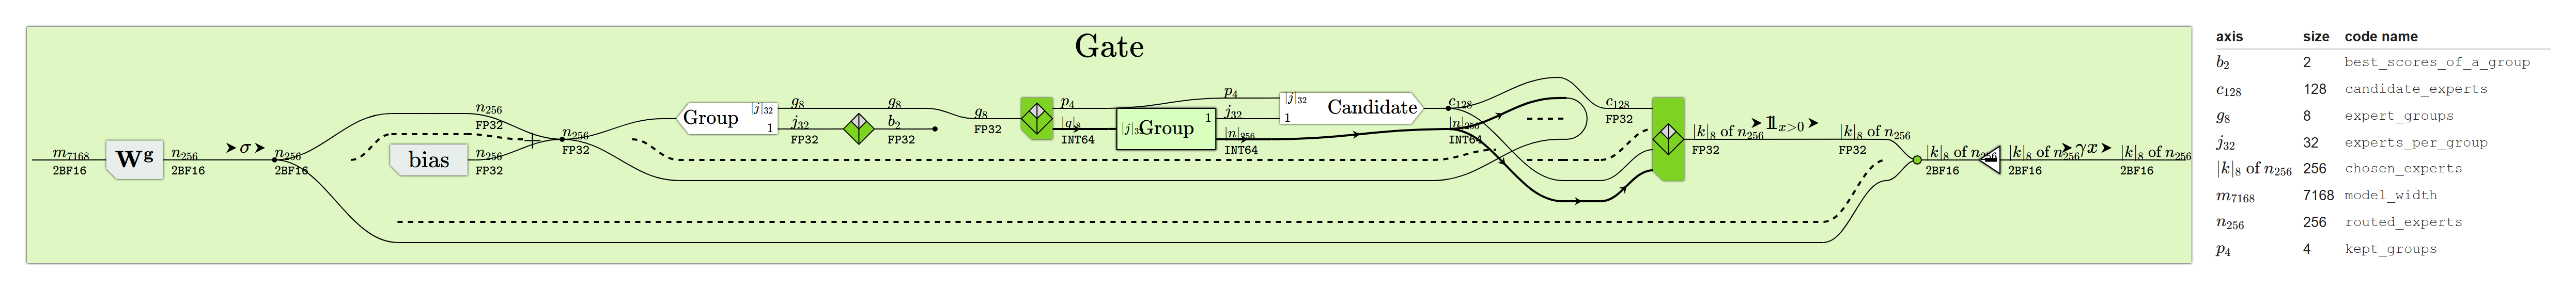

The rotary embedding at the quantisations of the released code: the pairs converted to FP32 for the product with the table, and the result converted back to BF16.


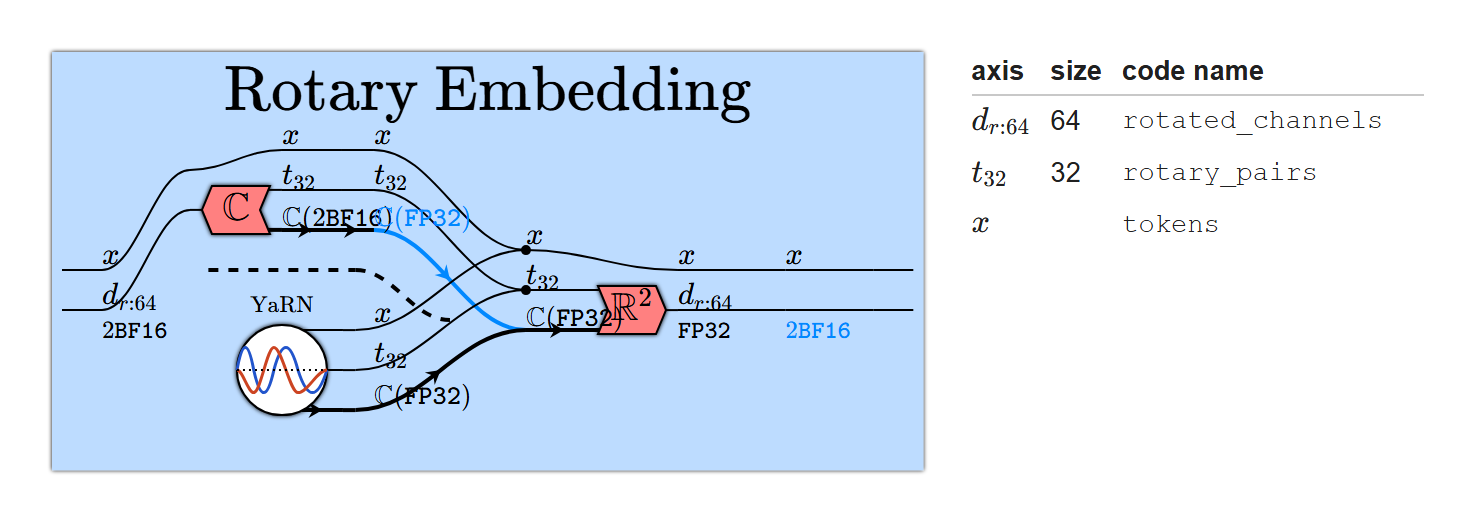

DeepSeek-V3 at the quantisations of the released code, with the token identifiers in INT64 and every other wire in BF16.


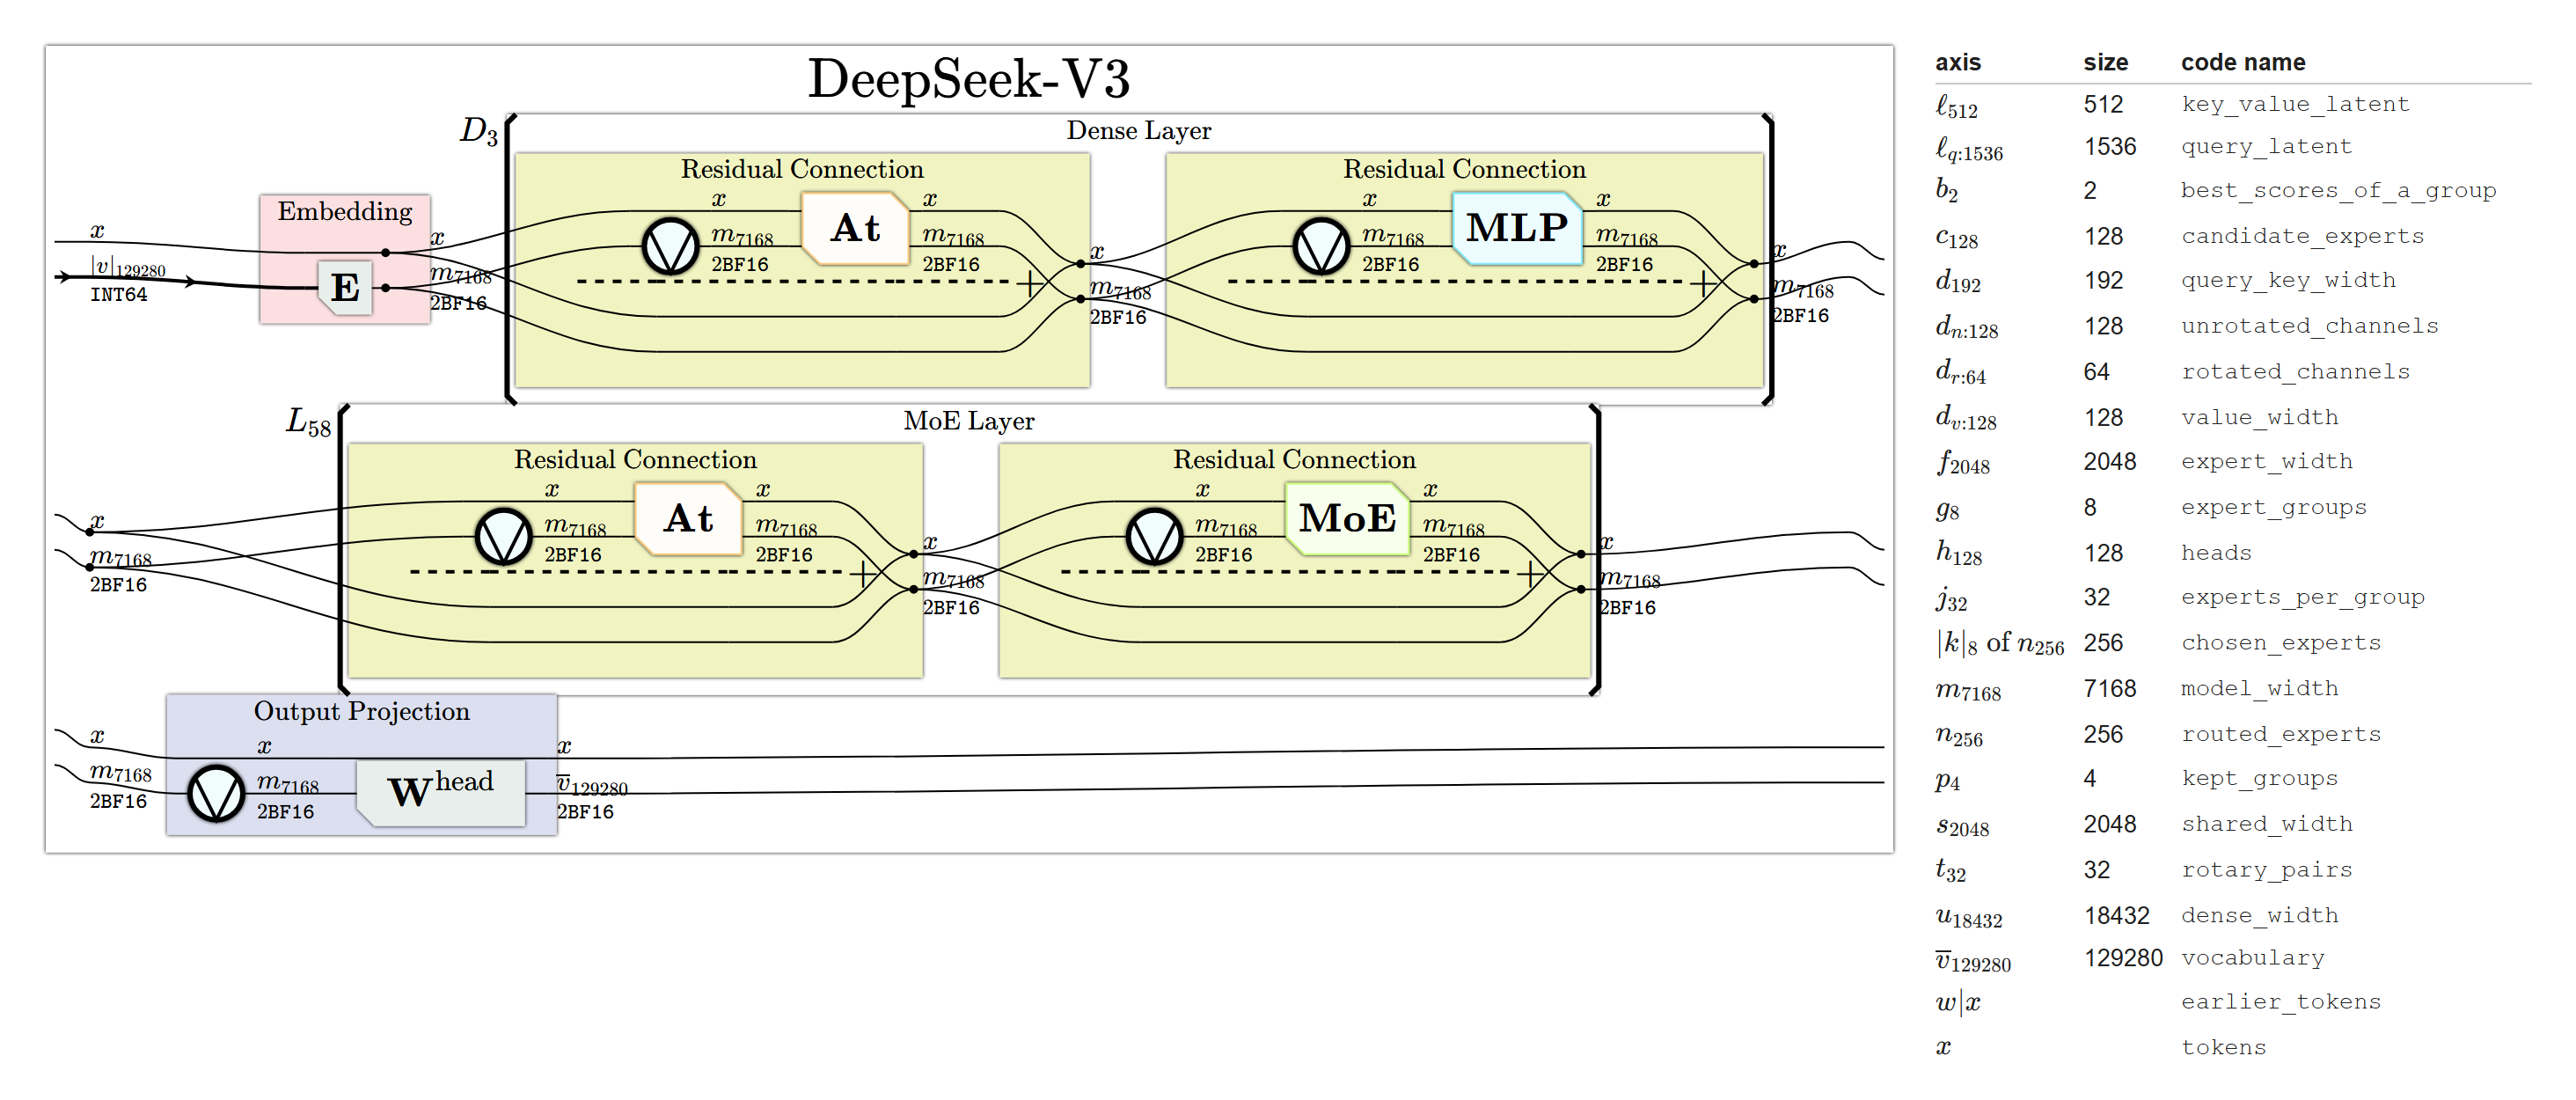

In [8]:
quantised_gate = released_deepseek_v3.box_named(
    released_deepseek_v3.GATE_BOX, quantised_deepseek_v3.decode_quantised)

await figures.show(
    quantised_gate.operator.block,
    'The gate of one token at the quantisations of the released code: the router in '
    'BF16, '
    'the biased copy of the scores and the choice of the experts in FP32, and the '
    'gates in BF16.',
    width=2300, settings=QUANTISED_DIAGRAMS)
await figures.show(
    released_deepseek_v3.box_named(
        deepseek_v3.ROTARY_EMBEDDING.operator.name.to_bodies(),
        quantised_deepseek_v3.decode_quantised).operator.block,
    'The rotary embedding at the quantisations of the released code: the pairs '
    'converted to '
    'FP32 for the product with the table, and the result converted back to BF16.',
    width=1200, settings=QUANTISED_DIAGRAMS)
await figures.show(
    quantised_deepseek_v3.decode_quantised,
    'DeepSeek-V3 at the quantisations of the released code, with the token identifiers '
    'in '
    'INT64 and every other wire in BF16.',
    width=960, sub_blocks=figures.SubBlocks.NO_BODIES, settings=QUANTISED_DIAGRAMS)

## The pass over the new tokens and its caches

A model that generates text runs one pass per step. A pass appends the new tokens $x_{\mathrm{new}}$ after the tokens $x_{\mathrm{old}}$ of the earlier passes and needs the results of the model at the new tokens alone. The pass is derived from the expression by carrying the read of the new tokens, $i_x = \lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}}$, back from the result. An operation computed at every token passes that read on to its operand. The causal mask composes with it into a read of the positions $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}} - i_w$, which include earlier tokens. The derivation places a cache on the operand of the mask. A cache appends the values of the new tokens to the values stored by the earlier passes and returns them all. The mask reads the cache.

A cache can stand after any operation between the copy of the hidden state and the mask, because each such operation is computed at every token and gives the same values when it is computed again over the cached tokens. The attention of DeepSeek-V3 has 26 such placements. The narrowest placement caches the normalised latent, 512 values per token, and the turned key, 64 values per token. It computes $W^{UK}$, $W^{UV}$, the copy of the turned key for every head and the join of the two runs of the key at every cached token. The derivation places the caches of all 61 layers that way, which holds 576 values per token in each layer and 35136 values per token in all.

In the order in which the model is written, that placement expands every cached latent through $W^{UK}$ and $W^{UV}$ in every pass. The score contracts the query with $W^{UK}$ applied to the latent, and the two sums can be taken in the other order: the query contracted with $W^{UK}$ first, and the result contracted with the cached latent. The weighted sum of the values can likewise sum the cached latent over the slots before $W^{UV}$ is applied. At one new token after 32768 earlier tokens, one layer of the attention takes $1.10 \times 10^{12}$ operations in the written order and $9.50 \times 10^{9}$ in the other. The derivation keeps the second order.

The released code runs this pass. Its `attn_impl` is `absorb` by default ([L17](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L17)). The absorb mode allocates one cache of the normalised latent and one of the turned key ([L443-L444](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L443-L444)). The pass writes `self.kv_norm(kv)` and the turned `k_pe` to them ([L484-L485](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L484-L485)), contracts the query with the key half of `wkv_b` before the scores ([L481-L487](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L481-L487)), and applies the value half after the weighted sum ([L494-L495](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L494-L495)). Both caches are created in the default dtype, so the released code holds them in BF16. The pass at the quantisations of the released code holds them in BF16 as well. The table of the rotary embedding depends on the position alone, so the pass computes it at every cached position and reads it at the positions of the new tokens.

values each cache of a layer holds per token: {'c_{RMSNorm}': 512, 'c_{RoPE}': 64}
values cached per token over the 61 layers: 35136
operations of one layer of the attention at one new token after 32768 earlier tokens: 1.10e+12 in the written order, 9.50e+09 in the absorbed order


The attention of one pass: the normalised latent and the turned key of the new tokens appended to their caches, the queries contracted with W^UK before the scores, and W^UV applied after the weighted sum, beside the rotary embedding of the pass, which reads its table at the positions of the new tokens.


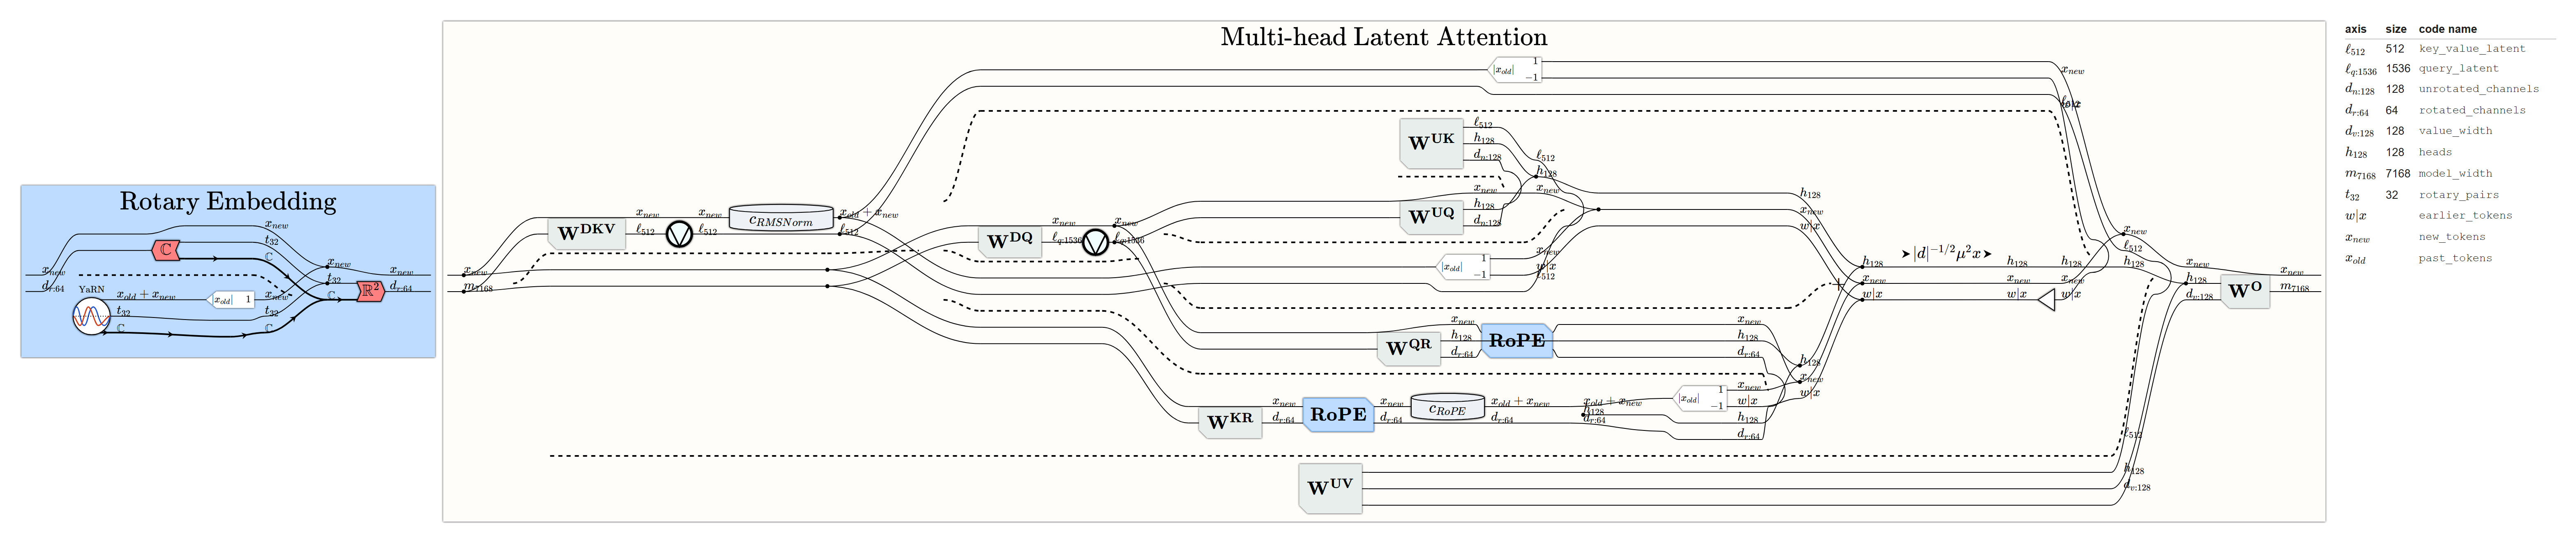

One pass of DeepSeek-V3 over the new tokens, whose every layer reads the cached latent and turned key of the earlier tokens inside the box At.


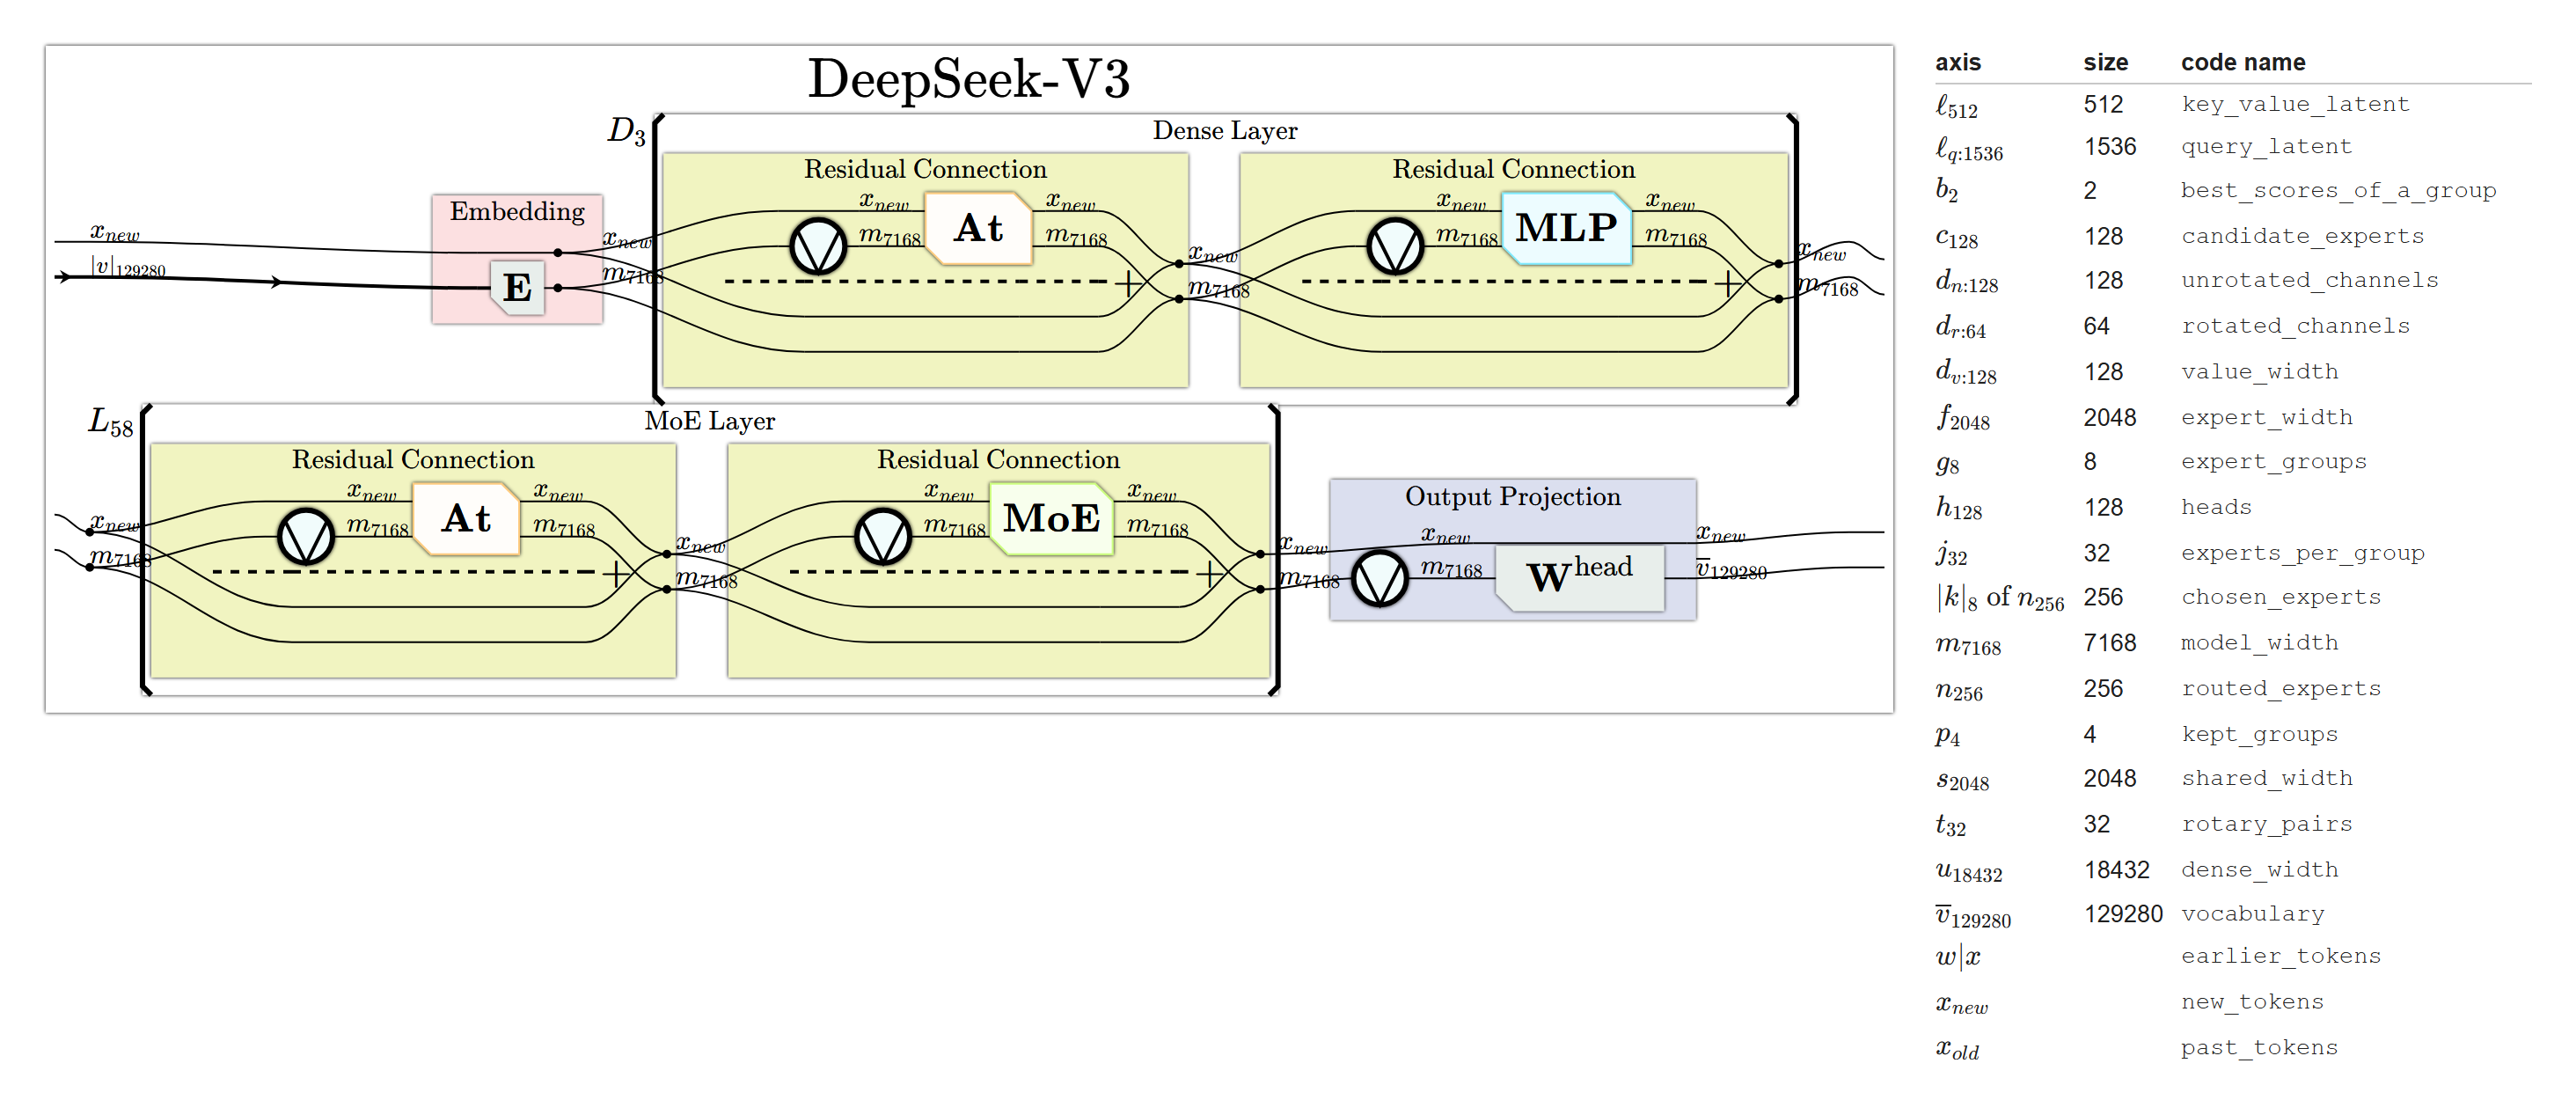

The attention of one pass at the quantisations of the released code, with both caches in BF16.


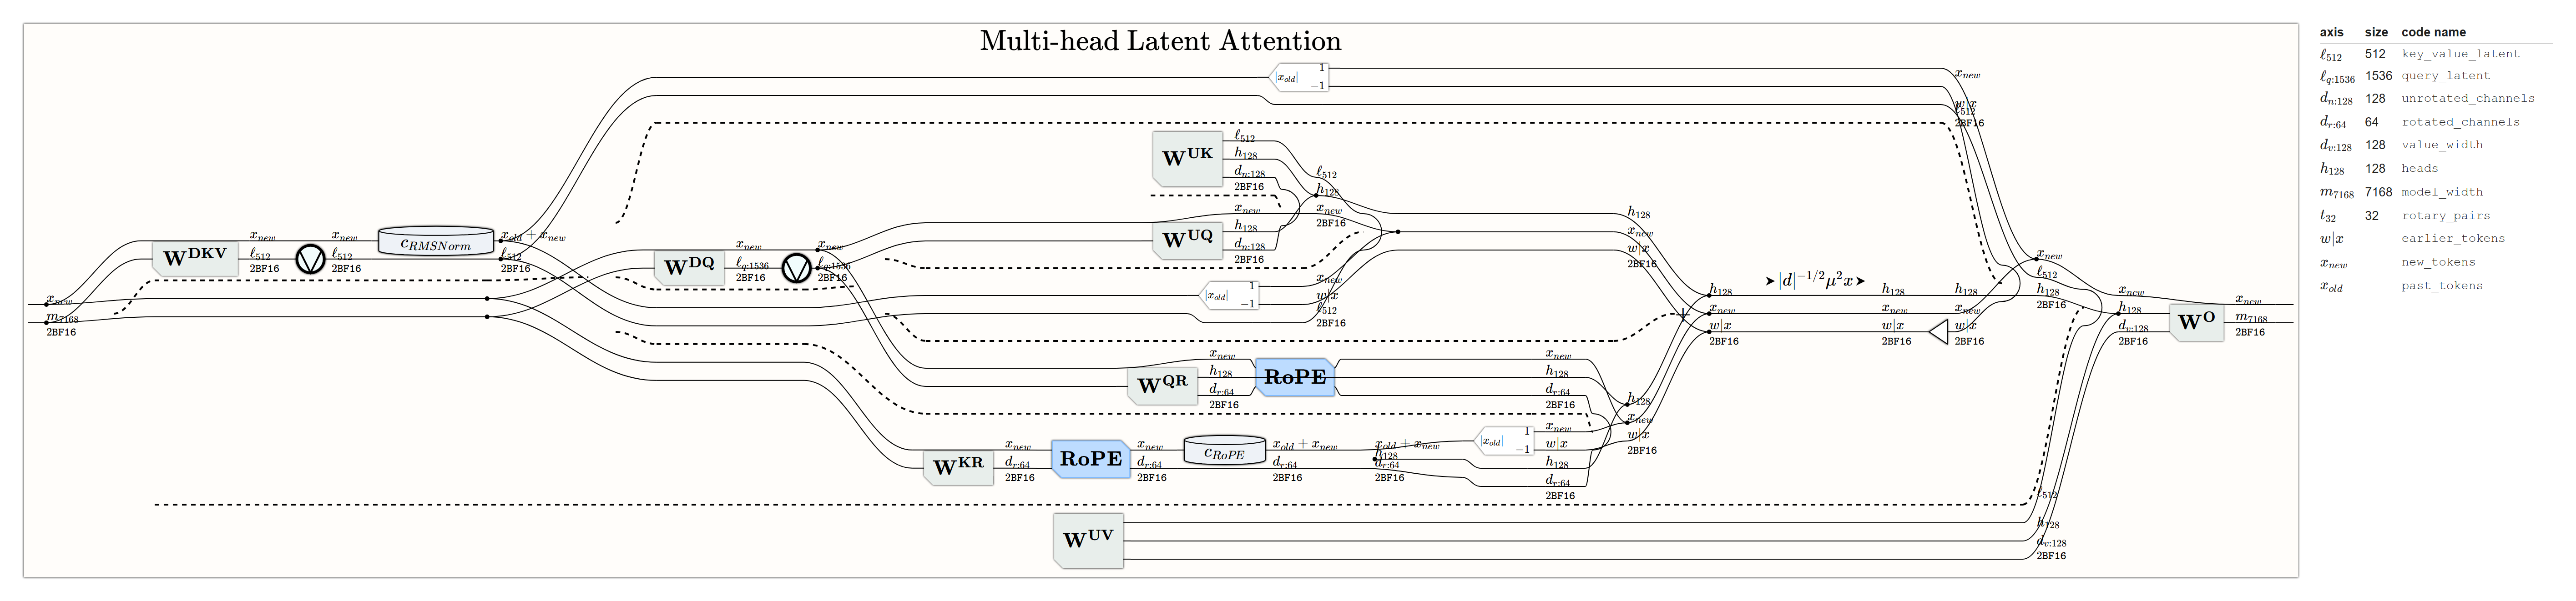

In [9]:
widths = cached_deepseek_v3.cache_widths_of_the_attention()
print('values each cache of a layer holds per token:', widths)
print('values cached per token over the 61 layers:',
      cached_deepseek_v3.values_cached_per_token())
written = cached_deepseek_v3.attention_operations(cached_deepseek_v3.WRITTEN_ORDER_PASS)
absorbed = cached_deepseek_v3.attention_operations(cached_deepseek_v3.CACHED_PASS)
print('operations of one layer of the attention at one new token after 32768 earlier '
      f'tokens: {written:.2e} in the written order, {absorbed:.2e} in the absorbed '
      'order')

await figures.show(
    cached_deepseek_v3.cached_attention().operator.block,
    'The attention of one pass: the normalised latent and the turned key of the new '
    'tokens appended to their caches, the queries contracted with W^UK before the '
    'scores, and W^UV applied after the weighted sum, beside the rotary embedding of '
    'the pass, which reads its table at the positions of the new tokens.',
    width=2200, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=CACHED_DIAGRAMS)
await figures.show(
    CACHED,
    'One pass of DeepSeek-V3 over the new tokens, whose every layer reads the cached '
    'latent and turned key of the earlier tokens inside the box At.',
    width=960, sub_blocks=figures.SubBlocks.NO_BODIES, settings=CACHED_DIAGRAMS)
quantised_cached_attention = released_deepseek_v3.box_named(
    deepseek_v3.ATTENTION_BOX, quantised_deepseek_v3.cached_quantised)

await figures.show(
    quantised_cached_attention.operator.block,
    'The attention of one pass at the quantisations of the released code, with both '
    'caches '
    'in BF16.',
    width=2600, sub_blocks=figures.SubBlocks.NO_BODIES,
    settings=QUANTISED_CACHED_DIAGRAMS)

## The interactive page

The last cell writes `notebooks/website/output/classic/DeepSeekV3/index.html`, one file that opens with no server and no network. A selector above the figure switches between the pass over every token of the sequence, under Decode, and the pass over the new tokens, under Cached, and between each pass at the quantisations of the released code and in the reals. The page holds the two passes at the quantisations of the released code. It derives each pass in the reals in the browser by removing every quantisation and every conversion between two quantisations, which leaves the expression the quantisations were written onto. Resting the pointer on a block or a box opens an inspection box with its title, its formula, its description and the released lines it expresses, and resting it on a weight opens a box naming the quantisation it is held in.

In [10]:
PAGE = dataclasses.replace(
    deepseek_v3_page_variants.page_settings(QUANTISED_DIAGRAMS),
    page_directory=website_output.CLASSIC_PAGES)

await notebook_diagrams.show_page_variants(
    deepseek_v3_page_variants.page_variants(PAGE),
    'DeepSeek-V3 as one HTML file with four forms: the pass over every token and the '
    'pass over the new tokens, each at the quantisations of the released code and in '
    'the '
    'reals, with an inspection box over every block and every operator.',
    settings=PAGE, slug=deepseek_v3_page_variants.SLUG,
    initial=deepseek_v3_page_variants.INITIAL_VARIANT)

DeepSeek-V3 as one HTML file with four forms: the pass over every token and the pass over the new tokens, each at the quantisations of the released code and in the reals, with an inspection box over every block and every operator.


(written to notebooks/website/output/classic/DeepSeekV3/)


## Differences from the released code

- The released code adds $-\infty$ to the scores of later tokens, and the expression reads the keys and the values through the view named Mask. Both leave each token reading itself and every earlier token.
- The released code holds $W^{UQ}$ with $W^{QR}$, $W^{DKV}$ with $W^{KR}$, and $W^{UK}$ with $W^{UV}$ as one weight each. The expression gives each part a weight of its own, and a block of 128 rows of the joined `wq_b` can hold rows of both parts.
- The released gate sets the biased scores of the groups it does not keep to $-\infty$ before it takes the eight best ([L591-L593](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L591-L593)). The expression lays the experts of the kept groups out as candidates and chooses among them. The two choose the same eight experts.
- The released gate reads the unbiased scores at the chosen positions ([L594](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L594)). The expression multiplies them by the indicator of a positive biased score, which is one at every chosen expert of the released weights.
- The routed experts are written as projections that hold the weights of every expert, read at the chosen experts. The released code loops over the experts and runs each one on the tokens that chose it ([L684-L689](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L684-L689)).
- The released forward pass keeps the last position alone ([L792](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L792)). The expression returns the scores of every position of the sequence, and the cached pass returns the scores of every new token.
- The checkpoint holds one module for multi-token prediction as layer 61, which `convert.py` skips ([`convert.py` L53-L54](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/convert.py#L53-L54)) and the released inference code does not run. The expression leaves it out.
- The released code splits the heads and the experts across GPUs and sums or gathers the results ([L416](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L416), [L691-L692](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L691-L692), [L794-L797](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L794-L797)). The expression holds every head and every expert.

## The references

The released code is `deepseek-ai/DeepSeek-V3` at commit [`9b4e978`](https://github.com/deepseek-ai/DeepSeek-V3/tree/9b4e9788e4a3a731f7567338ed15d3ec549ce03b), read on 2026-09-27. The checkpoint is `deepseek-ai/DeepSeek-V3` on Hugging Face at commit [`e815299`](https://huggingface.co/deepseek-ai/DeepSeek-V3/tree/e815299b0bcbac849fa540c768ef21845365c9eb), whose shard headers and correction biases were read on 2026-09-27. PyTorch is read at its tag `v2.4.1`, commit [`ee1b680`](https://github.com/pytorch/pytorch/tree/ee1b6804381c57161c477caa380a840a84167676). The technical report is arXiv [2412.19437](https://arxiv.org/pdf/2412.19437v2).

| mechanism | released code |
| --- | --- |
| sizes and defaults | [`model.py` L55-L86](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L55-L86), [`config_671B.json` L1-L22](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/configs/config_671B.json#L1-L22) |
| embedding, final norm and head | [`model.py` L764-L769](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L764-L769), [L792-L793](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L792-L793) |
| linear maps and the FP8 weights | [`model.py` L131-L205](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L131-L205), [`kernel.py` L60-L110](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/kernel.py#L60-L110), [`README_WEIGHTS.md` L60-L92](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/README_WEIGHTS.md#L60-L92) |
| RMSNorm | [`model.py` L270-L294](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L270-L294), [`layer_norm.cpp` L266-L309](https://github.com/pytorch/pytorch/blob/ee1b6804381c57161c477caa380a840a84167676/aten/src/ATen/native/layer_norm.cpp#L266-L309) |
| rotary embedding and YaRN | [`model.py` L297-L393](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L297-L393) |
| multi-head latent attention and its caches | [`model.py` L396-L497](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L396-L497) |
| causal mask | [`model.py` L788-L789](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L788-L789) |
| multi-layer perceptron and experts | [`model.py` L500-L532](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L500-L532), [L601-L633](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L601-L633) |
| gate | [`model.py` L535-L598](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L535-L598) |
| mixture of experts | [`model.py` L636-L693](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L636-L693) |
| layers and the model | [`model.py` L696-L798](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/model.py#L696-L798) |
| the default dtype and the run | [`generate.py` L81-L159](https://github.com/deepseek-ai/DeepSeek-V3/blob/9b4e9788e4a3a731f7567338ed15d3ec549ce03b/inference/generate.py#L81-L159) |

The expression is built in `notebooks/classic/released_deepseek_v3.py`, the quantisations are written onto it in `quantised_deepseek_v3.py`, and the cached pass is derived in `cached_deepseek_v3.py`, beside `deepseek_v3.py`, which holds the parts shared with the model of the hand-drawn diagram at [zardini.mit.edu/diagrams](https://zardini.mit.edu/diagrams/). `validate_deepseek_v3.py` beside this notebook checks every claim the notebook makes. The repository describes the derivation of the caches in `obsidian/08-caching/Deriving Caches by Dragging the New Tokens.md` and lists this notebook with the other classic models in `obsidian/06-practice/Notebooks.md`.